## FINLORA FINANCE FRAUD DETECTION & SCORING PROJECT ANALYSIS

## Business Prospects — 
Finlora a fintech company that provide transaction monitoring services to clients and merchandise. Due to increase data injection, their fixed monitoring threshold has failed to handle fraud transactions from legitimate transactions. A risk-scoring model built to detect fraud transaction from legitimate payroll, and device priority alerts to flag fraud transaction urgency regardless of actual risk.

## Business Problem — 
Replace rule-based monitoring missing subtle fraud as volume grows with a validated model that catches true fraud transactions.
Translating all information’s into Data driven task— binary classification of transactions as fraudulent vs. legitimate, with a probability score for prioritization.


## Analytical Framework:

| SN | NoteBook Outline |
|---|---|
| **1** | Problem definition document & data source inventory |
| **2** | Clean, analysis-ready dataset (transactions + accounts, joined and feature-engineered) |
| **3** | EDA summary report (fraud vs. legitimate patterns)|
| **4** | Feature importance / behavioral drivers document|
| **5** | Two trained models: Logistic Regression (baseline) + Random Forest (primary)|
| **6** | Model evaluation report (precision, recall, F1, ROC-AUC, confusion matrix, threshold analysis)|
| **7** | Deployed Streamlit dashboard: prioritized, explainable fraud review queue
| **8** | Final documentation + handover summary

## IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import probplot
import os
import joblib
import plotly.express as px

## LOAD DATASETS:

In [2]:
# 1. Load the first CSV file
account_data = pd.read_csv(
    r"C:\Users\User\Documents\AMDARI_IMS\Finlora_Finance_PJ\Dataset\Raw_data\finlora_accounts.csv")

# Data Summary
account_summary = pd.DataFrame({
    "Data Type": account_data.dtypes.astype(str),
    "Missing Values": account_data.isna().sum(),
    "% Missing Values": (account_data.isna().mean() * 100).round(2),
    "Unique Values": account_data.nunique(),
    "Duplicate Values": [account_data.duplicated(subset=[col]).sum() for col in account_data.columns]
}).sort_values(by="% Missing Values", ascending=False)

account_summary

,Data Type,Missing Values,% Missing Values,Unique Values,Duplicate Values
account_id,str,0,0.0,7200,0
account_holder_name,str,0,0.0,1000,6200
account_type,str,0,0.0,2,7198
home_country,str,0,0.0,5,7195
currency,str,0,0.0,4,7196
kyc_tier,str,0,0.0,3,7197
account_created_date,str,0,0.0,1443,5757
personal_spend_baseline_usd,float64,0,0.0,6309,891


In [3]:
account_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   account_id                   7200 non-null   str    
 1   account_holder_name          7200 non-null   str    
 2   account_type                 7200 non-null   str    
 3   home_country                 7200 non-null   str    
 4   currency                     7200 non-null   str    
 5   kyc_tier                     7200 non-null   str    
 6   account_created_date         7200 non-null   str    
 7   personal_spend_baseline_usd  7200 non-null   float64
dtypes: float64(1), str(7)
memory usage: 915.6 KB


In [4]:
# 2. Load the second CSV file
transaction_data = pd.read_csv(
    r"C:\Users\User\Documents\AMDARI_IMS\Finlora_Finance_PJ\Dataset\Raw_data\finlora_transactions.csv")

# Data Summary
transaction_summary = pd.DataFrame({
    "Data Type": transaction_data.dtypes.astype(str),
    "Missing Values": transaction_data.isna().sum(),
    "% Missing Values": (transaction_data.isna().mean() * 100).round(2),
    "Unique Values": transaction_data.nunique(),
    "Duplicate Values": [transaction_data.duplicated(subset=[col]).sum() for col in transaction_data.columns]
}).sort_values(by="% Missing Values", ascending=False)

transaction_summary

,Data Type,Missing Values,% Missing Values,Unique Values,Duplicate Values
merchant_name,str,28610,22.71,63,125936
is_new_device,float64,14334,11.38,2,125997
device_id,str,14334,11.38,14931,111068
transaction_id,str,0,0.00,126000,0
amount_to_avg_ratio,float64,0,0.00,5205,120795
status,str,0,0.00,3,125997
account_age_days,int64,0,0.00,1540,124460
is_cross_border,int64,0,0.00,2,125998
home_country,str,0,0.00,5,125995
transaction_country,str,0,0.00,5,125995


In [5]:
transaction_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   transaction_id              126000 non-null  str    
 1   account_id                  126000 non-null  str    
 2   account_type                126000 non-null  str    
 3   kyc_tier                    126000 non-null  str    
 4   timestamp                   126000 non-null  str    
 5   day_of_week                 126000 non-null  str    
 6   hour_of_day                 126000 non-null  int64  
 7   description                 126000 non-null  str    
 8   merchant_name               97390 non-null   str    
 9   merchant_category           126000 non-null  str    
 10  channel                     126000 non-null  str    
 11  amount                      126000 non-null  float64
 12  currency                    126000 non-null  str    
 13  amount_to_avg_ratio      

In [6]:
# 3. Merging the two datasets
# Remove duplicate account-level columns from Dataset 2
transaction_data = transaction_data.drop(
    columns=["account_type", "kyc_tier", "currency", "home_country"])

# Merge datasets
merged_data = pd.merge(account_data, transaction_data, on="account_id", how="inner")

# Display columns
print("Merged Dataset Columns:")
print(merged_data.columns.tolist())

# Merged Data Summary
merged_summary = pd.DataFrame({
    "Data Type": merged_data.dtypes.astype(str),
    "Missing Values": merged_data.isna().sum(),
    "% Missing Values": (merged_data.isna().mean() * 100).round(2),
    "Unique Values": merged_data.nunique(),
    "Duplicate Values": [merged_data.duplicated(subset=[col]).sum() for col in merged_data.columns]
}).sort_values(by="% Missing Values", ascending=False)

merged_summary


Merged Dataset Columns:
['account_id', 'account_holder_name', 'account_type', 'home_country', 'currency', 'kyc_tier', 'account_created_date', 'personal_spend_baseline_usd', 'transaction_id', 'timestamp', 'day_of_week', 'hour_of_day', 'description', 'merchant_name', 'merchant_category', 'channel', 'amount', 'amount_to_avg_ratio', 'avg_transaction_amount_30d', 'transaction_velocity_1h', 'transaction_country', 'is_cross_border', 'device_id', 'is_new_device', 'account_age_days', 'status', 'is_fraud']


,Data Type,Missing Values,% Missing Values,Unique Values,Duplicate Values
merchant_name,str,28610,22.71,63,125936
is_new_device,float64,14334,11.38,2,125997
device_id,str,14334,11.38,14931,111068
merchant_category,str,0,0.00,15,125985
status,str,0,0.00,3,125997
account_age_days,int64,0,0.00,1540,124460
is_cross_border,int64,0,0.00,2,125998
transaction_country,str,0,0.00,5,125995
transaction_velocity_1h,int64,0,0.00,4,125996
avg_transaction_amount_30d,float64,0,0.00,74185,51815


In [7]:
# 4. Save the merged dataset as a new CSV file
output_folder = r"C:\Users\User\Documents\AMDARI_IMS\Finlora_Finance_PJ\Dataset\Merged_data"

os.makedirs(output_folder, exist_ok=True)

# Save the merged dataset
output_file = os.path.join(
    output_folder,
    "finlora_merged.csv"
)

merged_data.to_csv(
    output_file,
    index=False
)

# 5. Confirm the result
print("Merged dataset created successfully!")
print("Rows and columns:", merged_data.shape)
print("File saved as: finlora_merged.csv")

Merged dataset created successfully!
Rows and columns: (126000, 27)
File saved as: finlora_merged.csv


## Investigating the Project Target Variable

In [8]:
print(merged_data["is_fraud"].value_counts())
print("="*20)
fraud_distribution = (merged_data["is_fraud"].value_counts(normalize=True).mul(100).round(2))

print(fraud_distribution)

is_fraud
0    122648
1      3352
Name: count, dtype: int64
is_fraud
0    97.34
1     2.66
Name: proportion, dtype: float64


In [11]:
# Visulization of the target variable
fraud_distribution = (merged_data["is_fraud"].value_counts(normalize=True).mul(100).round(2).reset_index())

fraud_distribution.columns = ["is_fraud", "proportion"]

# Convert fraud codes to meaningful labels
fraud_distribution["is_fraud"] = fraud_distribution["is_fraud"].map({0: "Legitimate", 1: "Fraud"})

fig = px.sunburst(fraud_distribution, path=["is_fraud"], values="proportion", title="Fraud Distribution")

fig.update_layout(plot_bgcolor="white", paper_bgcolor="white", showlegend=False,  width=800, height=500,)

fig.show()

## Data Quality Assessment

### Handling Missing Dataset:

In [12]:
# ----------------------------------------------------------
# 1. Check missing values before treatment
# ----------------------------------------------------------
'''
Create a dataframe to show total number of missing values
and percentage of missing values in merged data
'''

missing_data = pd.DataFrame({"Missing Data": merged_data.isnull().sum(), "Missing Percentage": (merged_data.isnull().mean() * 100).round(2)})

# Show only columns that contain missing values
missing_data = (missing_data[missing_data["Missing Data"] > 0].sort_values("Missing Percentage", ascending=False))

print("Missing values BEFORE treatment:")
print("--"*25)
print(missing_data)
print()


# Visualizing the Missing Data
print("Visaulization of Missing values BEFORE treatment:")
print("--"*25)
fig = px.bar(missing_data, x=missing_data.index, y="Missing Percentage",
             title="Missing Data Percentage by Feature",
             labels={"x": "Features", "Missing Percentage": "Missing Percentage (%)"},
             text="Missing Percentage")

fig.update_traces( texttemplate="%{text:.2f}%", textposition="outside")

fig.update_layout(showlegend=False, plot_bgcolor="white", paper_bgcolor="white",
                  xaxis=dict(showgrid=False, tickangle=-45), yaxis=dict(showgrid=False))

fig.show()

Missing values BEFORE treatment:
--------------------------------------------------
               Missing Data  Missing Percentage
merchant_name         28610               22.71
device_id             14334               11.38
is_new_device         14334               11.38

Visaulization of Missing values BEFORE treatment:
--------------------------------------------------


In [ ]:
# Checking for outliers in the numerical columns
# Since outliers are only posssible in numerical data, let's analyze the numerical columns
merged_data.select_dtypes('number').columns.to_list()

['personal_spend_baseline_usd',
 'hour_of_day',
 'amount',
 'amount_to_avg_ratio',
 'avg_transaction_amount_30d',
 'transaction_velocity_1h',
 'is_cross_border',
 'is_new_device',
 'account_age_days',
 'is_fraud']

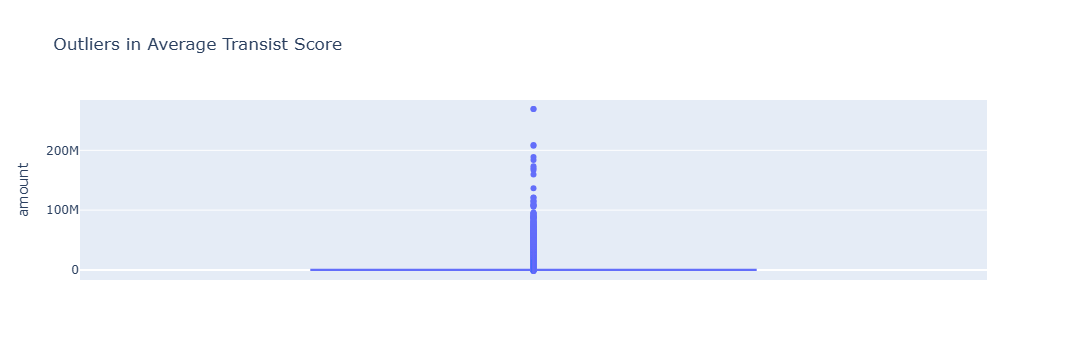

In [ ]:
fig=px.box(merged_data,y='amount',points='outliers', title='Outliers in Average Transist Score')

fig.update_layout(hovermode='x')

In [ ]:
# ----------------------------------------------------------------
# 2. Identify numerical and categorical columns with missing data
# ----------------------------------------------------------------
'''
Since this missing values are tracnsaction amount, its is best to use median
'''
numeric_columns = merged_data.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_columns = merged_data.select_dtypes(include=["object", "category"]).columns.tolist()


# ----------------------------------------------------------
# 3. Fill numerical missing values with median
# ----------------------------------------------------------

for column in numeric_columns:
    if merged_data[column].isnull().sum() > 0:
        median_value = merged_data[column].median()merged_data[column] = merged_data[column].fillna(median_value)

C:\Users\User\AppData\Local\Temp\ipykernel_18452\325544037.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = merged_data.select_dtypes(


In [ ]:
# ----------------------------------------------------------
# 4. Fill categorical missing values with mode
# ----------------------------------------------------------

for column in categorical_columns:
    if  merged_data[column].isnull().sum() > 0:
        mode_value =  merged_data[column].mode()
        if not mode_value.empty:
            merged_data[column] =  merged_data[column].fillna(mode_value[0])


# ----------------------------------------------------------
# 5. Check missing values AFTER treatment
# ----------------------------------------------------------

missing_after = pd.DataFrame({"Missing_Count":  merged_data.isnull().sum(), "Missing_Percentage": (merged_data.isnull().mean() * 100).round(2)})

missing_after = missing_after[missing_after["Missing_Count"] > 0]

print("\nMissing values AFTER treatment:")
if missing_after.empty:
    print("No missing values remain.")
else:
    print(missing_after)


# ----------------------------------------------------------
# 6. Final check
# ----------------------------------------------------------

total_missing =  merged_data.isnull().sum().sum()

print("\nTotal missing values:", total_missing)

print("\nDataset shape:", merged_data.shape)


Missing values AFTER treatment:
No missing values remain.

Total missing values: 0

Dataset shape: (126000, 27)


## Check For Duplicate Data

In [ ]:
print("Duplicate rows:",merged_data.duplicated().sum())
duplicates = merged_data.drop_duplicates().reset_index(drop=True)
print("="*20)

print("Dataset shape after removing duplicates:", duplicates.shape)

Duplicate rows: 0
Dataset shape after removing duplicates: (126000, 27)


In [ ]:
# Check duplicate transaction_id
print("Duplicate transaction IDs:", merged_data["transaction_id"].duplicated().sum())

duplicate_transactions = merged_data[merged_data["transaction_id"].duplicated(keep=False)]

print(duplicate_transactions.head())

Duplicate transaction IDs: 0
Empty DataFrame
Columns: [account_id, account_holder_name, account_type, home_country, currency, kyc_tier, account_created_date, personal_spend_baseline_usd, transaction_id, timestamp, day_of_week, hour_of_day, description, merchant_name, merchant_category, channel, amount, amount_to_avg_ratio, avg_transaction_amount_30d, transaction_velocity_1h, transaction_country, is_cross_border, device_id, is_new_device, account_age_days, status, is_fraud]
Index: []

[0 rows x 27 columns]


In [ ]:
# Check duplicate account_id
print("Duplicate Account IDs:", merged_data["account_id"].duplicated().sum())

duplicate_transactions = merged_data[merged_data["account_id"].duplicated(keep=False)]

print(duplicate_transactions.head())

print("Unique accounts:", merged_data["account_id"].nunique())

print("Unique transactions:", merged_data["transaction_id"].nunique())

Duplicate Account IDs: 118856
       account_id account_holder_name account_type home_country currency  \
0  FLR-ACC-100000        Amaka Okafor   Individual           NG      NGN   
1  FLR-ACC-100000        Amaka Okafor   Individual           NG      NGN   
2  FLR-ACC-100000        Amaka Okafor   Individual           NG      NGN   
3  FLR-ACC-100000        Amaka Okafor   Individual           NG      NGN   
4  FLR-ACC-100000        Amaka Okafor   Individual           NG      NGN   

         kyc_tier account_created_date  personal_spend_baseline_usd  \
0  Tier3_Enhanced           2022-08-28                        63.23   
1  Tier3_Enhanced           2022-08-28                        63.23   
2  Tier3_Enhanced           2022-08-28                        63.23   
3  Tier3_Enhanced           2022-08-28                        63.23   
4  Tier3_Enhanced           2022-08-28                        63.23   

    transaction_id            timestamp  ... amount_to_avg_ratio  \
0  FLR250216186265

### Save the Cleaned Dataset

In [13]:
# Save the cleaned dataset as a new CSV file
output_folder = r"C:\Users\User\Documents\AMDARI_IMS\Finlora_Finance_PJ\Dataset\preprocessed_dataset"

os.makedirs(output_folder, exist_ok=True)

# Save the cleaned dataset
output_file = os.path.join(output_folder, "finlora_cleaned_data.csv")

merged_data.to_csv(output_file, index=False)

# 5. Confirm the result
print("Cleaned dataset created successfully!")
print("Rows and columns:", merged_data.shape)
print("File saved as: finloar_cleaned_data.csv")

Cleaned dataset created successfully!
Rows and columns: (126000, 27)
File saved as: finloar_cleaned_data.csv
